# Lab 5 — Visual SLAM Using Convolutional Neural Network

## Building Visual Perception and SLAM Capability for the Warehouse AMR

## 1. Experiment Objective

In this laboratory, we will extend our warehouse mobile robot with a
vision-based perception and mapping capability.

The robot is equipped with an RGB camera. As the robot moves through
the warehouse, consecutive camera images contain information about
the surrounding environment and the robot's motion.

The objective of this experiment is to understand and implement a
Visual SLAM pipeline in which a Convolutional Neural Network (CNN)
is used to obtain learned visual representations that contribute to
the visual perception stage of SLAM.

By the end of the experiment, you should be able to:

1. Explain the role of a camera in Visual SLAM.
2. Understand the difference between visual odometry and Visual SLAM.
3. Extract useful visual representations from camera images.
4. Use CNN-based visual features within a Visual SLAM pipeline.
5. Estimate camera/robot motion from successive observations.
6. Visualize the estimated trajectory and reconstructed environment.
7. Interpret how visual perception affects SLAM performance.
8. Identify practical limitations of vision-based SLAM in a warehouse.

## 2. Connection to Lecture 9

In Lecture 8, we learned how a robot can build an occupancy grid by
accumulating sensor observations over time.

We then identified an important limitation:

> Mapping requires knowledge of the robot's pose.

If the robot's pose estimate is inaccurate, sensor observations may be
inserted into the wrong locations and the resulting map can become
distorted.

This leads to the SLAM problem:

$$
\boxed{
\text{Simultaneous Localization and Mapping}
}
$$

In Lecture 9, we studied:

- SLAM as a coupled estimation problem
- Feature-based and grid-based SLAM
- Graph SLAM
- FastSLAM
- Visual SLAM
- Neural-network-based Visual SLAM

In this laboratory, we move from the theory to implementation.

Our focus is the camera-based case:
$$
\boxed{
\text{Camera Images}
\rightarrow
\text{Visual Features}
\rightarrow
\text{Motion Estimation}
\rightarrow
\text{Mapping}
\rightarrow
\text{Visual SLAM}
}
$$

The CNN will be introduced as a learned visual representation
component within this pipeline.

## 3. Our Running Robot: Warehouse AMR

Throughout this course, we use the same differential-drive warehouse
mobile robot.

The robot is equipped with:

- Wheel encoders
- IMU
- 2D LiDAR
- RGB camera
- Onboard computer

In previous laboratories, we progressively developed the robot's:

- motion model
- sensor models
- localization capability

We now add another capability:

$$
\boxed{
\text{Visual Perception + SLAM}
}
$$

### Scenario

The AMR is moving through a warehouse containing:

- storage racks
- workstations
- aisle boundaries
- structural features
- other visually distinguishable objects

The robot does not receive a pre-built visual map.

Instead, it observes the environment through its camera while moving.

Our task is to use these observations to estimate the robot's motion
and construct a representation of the environment.

## 4. Think First: What Can a Camera Tell the Robot?

Imagine that the warehouse AMR takes the following two images:

$$
I_t
\qquad\text{and}\qquad
I_{t+1}
$$

The robot has moved between these two observations.

### Think about the following questions before running any code:

1. What information is common between the two images?

2. If the robot moves forward, how should visible objects appear
   differently in the second image?

3. Can the robot use these changes to estimate its own motion?

4. If the robot observes the same physical location again later,
   how could it recognize that it has returned to a previously
   observed place?

5. What additional information is required to convert image
   observations into a spatial map?

Do not worry about the implementation yet.

The goal is to identify the information flow that a Visual SLAM
system must perform.

## 5. Visual SLAM: The Big Picture

A simplified Visual SLAM pipeline can be viewed as:

$
\boxed{
\text{Camera}
}
$

↓

$
\boxed{
\text{Visual Representation}
}
$

↓

$
\boxed{
\text{Feature Detection / Description}
}
$

↓

$
\boxed{
\text{Feature Correspondence}
}
$

↓

$
\boxed{
\text{Motion Estimation}
}
$

↓

$
\boxed{
\text{Map Construction}
}
$

↓

$
\boxed{
\text{Trajectory + Map}
}
$

A neural network can contribute to the visual representation stage by
learning features that are useful for recognizing visual structure.

Therefore, in this laboratory we will investigate the following
hybrid pipeline:

$$
\boxed{
\text{Camera Images}
\rightarrow
\text{CNN Features}
\rightarrow
\text{Visual Matching}
\rightarrow
\text{Motion Estimation}
\rightarrow
\text{Mapping}
}
$$

### Important

A CNN does not automatically solve the complete SLAM problem.

SLAM still requires:

- estimation of robot/camera motion,
- geometric reasoning,
- accumulation of observations,
- and map construction.

The purpose of the neural network is to provide a learned visual
representation that can improve the perception stage.

## 6. Visual Odometry vs Visual SLAM

These two terms are related but they are not identical.

### Visual Odometry

Visual odometry estimates the motion of the camera or robot from
visual observations.

Conceptually:

$$
I_t,I_{t+1}
\rightarrow
\Delta x_t
$$

where $\Delta x_t$ represents the estimated motion between
successive observations.

### Visual SLAM

Visual SLAM goes further.

It estimates:

1. the robot trajectory, and
2. a representation of the environment.

Conceptually:

$$
\boxed{
\text{Images}
\rightarrow
\text{Trajectory}
+
\text{Map}
}
$$

Therefore:

$$
\boxed{
\text{Visual Odometry}
\subset
\text{Visual SLAM pipeline}
}
$$

### Think First

If a system estimates the robot's motion from camera images but does
not maintain a map of the environment, should we call it Visual SLAM?

**Answer this before continuing.**

## 7. Laboratory Roadmap

We will develop the experiment progressively.

### Part A — Understand the Visual Data

- Load the camera sequence
- Inspect individual frames
- Understand the image sequence
- Observe how the scene changes as the robot moves

### Part B — Establish a Visual Baseline

- Detect visual structure
- Identify corresponding observations
- Estimate motion between frames
- Visualize the resulting trajectory

### Part C — Introduce CNN-Based Visual Representation

- Understand why learned visual features can be useful
- Load a CNN-based feature extractor
- Generate visual representations from camera images
- Compare their behaviour with conventional visual representations

### Part D — Integrate With the SLAM Pipeline

- Use visual correspondences for motion estimation
- Accumulate the estimated motion
- Construct a map/trajectory representation
- Visualize the result

### Part E — Experiment and Interpret

- Modify relevant parameters
- Observe the effect on feature matching and trajectory estimation
- Identify failure cases
- Discuss implications for a real warehouse AMR

## 8. What You Should Be Able to Explain at the End

By the end of this laboratory, you should be able to answer:

### Conceptual

- What is Visual SLAM?
- How is Visual SLAM different from Visual Odometry?
- Why are visual features important?
- What role can a CNN play in Visual SLAM?

### Technical

- How are visual observations obtained from consecutive frames?
- How can corresponding visual information be identified?
- How can camera motion be estimated?
- How can motion estimates be accumulated into a trajectory?
- How can the observed environment be represented?

### Engineering

- What happens when there are too few visual features?
- How do lighting changes affect visual matching?
- Why can repetitive warehouse structures create ambiguity?
- What happens when the robot moves too quickly?
- Why is camera placement important on a warehouse AMR?
- Where would a CNN-based approach be useful in a real deployment?

## 9. How to Use This Notebook

Do not treat this notebook as a sequence of code cells that must simply
be executed.

For each activity:

1. **Understand** — read the concept and identify the robotics problem.
2. **Run** — execute the provided implementation.
3. **Observe** — inspect the numerical and visual output.
4. **Modify** — change selected parameters or implementation choices.
5. **Explain** — connect the observed behaviour to the underlying
   robotics concept.

You are not expected to implement an industrial-grade SLAM system
from scratch.

The objective is to understand the complete processing pipeline and
to experimentally observe how its components affect robot motion
estimation and mapping.

# Part A — Understanding the Visual Input

Before implementing Visual SLAM, we first need to understand the
information available to the robot.

Our warehouse AMR is equipped with an RGB camera.

The camera provides a sequence of images:

$$
I_1,I_2,I_3,\ldots,I_T
$$

where each image corresponds to a different point in the robot's
motion through the environment.

The Visual SLAM system will use changes and similarities between these
images to estimate motion and understand the environment.

## 10. Required Python Libraries

In this laboratory we will use:

- NumPy — numerical operations
- Matplotlib — visualization
- OpenCV — image processing and visual features
- PyTorch — CNN-based visual representation

The course environment is cumulative. We do not create a new Python
environment for this laboratory.

If a new dependency is required, it should be added to the existing
course environment and cumulative `requirements.txt`.

We will first verify that the required libraries are available before
continuing.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch

print("NumPy version   :", np.__version__)
print("OpenCV version  :", cv2.__version__)
print("PyTorch version :", torch.__version__)

NumPy version   : 2.3.5
OpenCV version  : 5.0.0
PyTorch version : 2.14.1


## 11. Environment Check

Before proceeding, verify the following:

- NumPy imports successfully.
- Matplotlib imports successfully.
- OpenCV imports successfully.
- PyTorch imports successfully.

If an import fails, stop here and resolve the environment issue before
continuing.

Do not modify the remaining notebook to work around a missing
dependency.

### Engineering Practice

A robotics algorithm is only useful if its computational environment
is reproducible.

Therefore, environment verification is part of the experiment rather
than an administrative step.

An RGB camera image can be represented mathematically as a three-
dimensional array:

$$
I \in \mathbb{R}^{H\times W\times 3}
$$

where:

- $H$ = image height
- $W$ = image width
- $3$ = RGB colour channels

For example, an image with resolution $640\times480$ contains:

$$
480\times640\times3
$$

values.

The important point is that a camera does not directly provide:

$$
(x,y,\theta)
$$

Instead, it provides visual observations.

The SLAM system must extract useful information from those observations.

## 13. Think First — What Changes When the Robot Moves?

Suppose the robot captures two consecutive images:

$$
I_t
\qquad\text{and}\qquad
I_{t+1}
$$

The robot has moved between these observations.

### Predict before running the next cell:

1. Will every pixel remain unchanged?

2. Will some parts of the image remain visually similar?

3. Which parts of the image are likely to be useful for estimating
   motion?

4. What would happen if the image contained a completely uniform wall?

5. What would happen if the image contained many distinctive
   structures such as corners, rack edges, or labels?

Write down your prediction before continuing.

# Part A — Understanding the Visual Dataset

Before extracting visual features, we first need to understand exactly
what information is available in our dataset.

The dataset was generated from the simulated warehouse AMR using MuJoCo.

Each sample contains:

- an RGB camera image
- the AMR ground-truth position $(x,y)$
- the AMR orientation $\theta$

The dataset contains controlled variations in:

- robot position
- robot orientation

This is useful because we can study how visual observations change
when we deliberately change the robot pose.

### Important

The images in this dataset are **not a natural time-ordered trajectory**.

For example:

$$
\text{frame}_{0001}
\rightarrow
\text{frame}_{0002}
\rightarrow
\text{frame}_{0003}
$$

should **not** automatically be interpreted as consecutive robot
observations during motion.

Instead, we will select images with controlled pose changes so that
we can understand the relationship between:

$$
\boxed{
\text{Robot Pose}
\rightarrow
\text{Camera Observation}
}
$$

This controlled structure will allow us to evaluate the visual
processing pipeline before introducing motion estimation.

In [10]:
import os
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt


# Dataset paths
DATASET_DIR = "data/dataset_v2"
IMAGE_DIR = os.path.join(DATASET_DIR, "images")
METADATA_PATH = os.path.join(DATASET_DIR, "metadata.csv")


print("Dataset directory :", DATASET_DIR)
print("Image directory   :", IMAGE_DIR)
print("Metadata file     :", METADATA_PATH)

Dataset directory : data/dataset_v2
Image directory   : data/dataset_v2/images
Metadata file     : data/dataset_v2/metadata.csv


In [11]:
metadata = pd.read_csv(METADATA_PATH)

print("Number of records:", len(metadata))
print()
print(metadata.head())

Number of records: 175

   sample_id  image_filename    x    y  theta_deg  theta_rad
0          1  frame_0001.png  0.0 -2.0      -45.0  -0.785398
1          2  frame_0002.png  0.0 -2.0      -30.0  -0.523599
2          3  frame_0003.png  0.0 -2.0      -15.0  -0.261799
3          4  frame_0004.png  0.0 -2.0        0.0   0.000000
4          5  frame_0005.png  0.0 -2.0       15.0   0.261799


In [12]:
print("Dataset shape:", metadata.shape)
print()

print("Columns:")
for column in metadata.columns:
    print(" -", column)

print()

print("Unique X positions :", metadata["x"].nunique())
print("Unique Y positions :", metadata["y"].nunique())
print("Unique orientations:", metadata["theta_deg"].nunique())

print()

print("X positions:")
print(sorted(metadata["x"].unique()))

print()

print("Y positions:")
print(sorted(metadata["y"].unique()))

print()

print("Orientations (degrees):")
print(sorted(metadata["theta_deg"].unique()))

Dataset shape: (175, 6)

Columns:
 - sample_id
 - image_filename
 - x
 - y
 - theta_deg
 - theta_rad

Unique X positions : 5
Unique Y positions : 5
Unique orientations: 7

X positions:
[np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0)]

Y positions:
[np.float64(-2.0), np.float64(-1.75), np.float64(-1.5), np.float64(-1.25), np.float64(-1.0)]

Orientations (degrees):
[np.float64(-45.0), np.float64(-30.0), np.float64(-15.0), np.float64(0.0), np.float64(15.0), np.float64(30.0), np.float64(45.0)]


## A1. Pose Coverage

The dataset was deliberately generated using a Cartesian combination of:

- 5 X positions
- 5 Y positions
- 7 orientations

Therefore, the expected number of poses is:

$$
5 \times 5 \times 7 = 175
$$

This gives us controlled coverage of the robot's position and
orientation.

Such controlled variation is useful for experimentation because we can
change one variable while keeping the others fixed.

In [13]:
expected_samples = (
    metadata["x"].nunique()
    * metadata["y"].nunique()
    * metadata["theta_deg"].nunique()
)

actual_samples = len(metadata)

print("Expected samples:", expected_samples)
print("Actual samples  :", actual_samples)

assert actual_samples == expected_samples, (
    "Dataset size does not match the expected Cartesian pose coverage."
)

print("\nPose coverage check: PASSED")

Expected samples: 175
Actual samples  : 175

Pose coverage check: PASSED


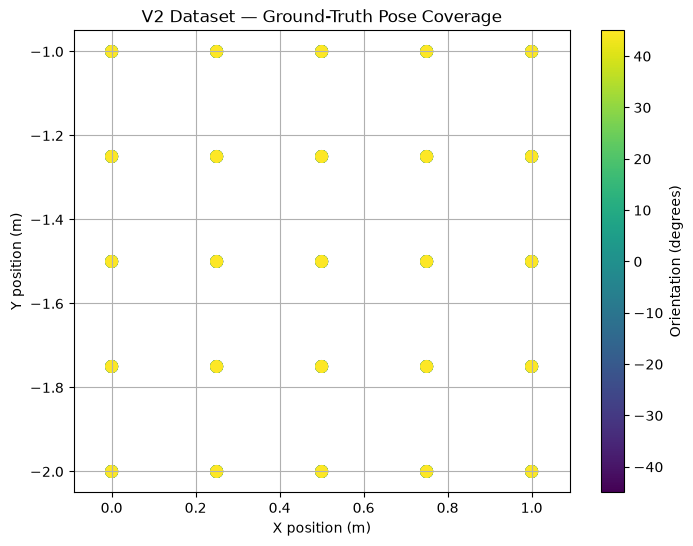

In [14]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    metadata["x"],
    metadata["y"],
    c=metadata["theta_deg"],
    cmap="viridis",
    s=70
)

plt.xlabel("X position (m)")
plt.ylabel("Y position (m)")
plt.title("V2 Dataset — Ground-Truth Pose Coverage")

cbar = plt.colorbar(scatter)
cbar.set_label("Orientation (degrees)")

plt.grid(True)
plt.axis("equal")
plt.show()

In [15]:
def load_image(filename):
    """
    Load an RGB image from the dataset.
    """
    
    image_path = os.path.join(IMAGE_DIR, filename)

    image_bgr = cv2.imread(image_path)

    if image_bgr is None:
        raise FileNotFoundError(
            f"Could not load image: {image_path}"
        )

    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB
    )

    return image_rgb

In [16]:
sample = metadata.iloc[0]

image = load_image(sample["image_filename"])

print("Image shape :", image.shape)
print("Image dtype :", image.dtype)
print("Robot pose  :")
print(f"  x     = {sample['x']:.2f} m")
print(f"  y     = {sample['y']:.2f} m")
print(f"  theta = {sample['theta_deg']:.1f}°")

Image shape : (480, 640, 3)
Image dtype : uint8
Robot pose  :
  x     = 0.00 m
  y     = -2.00 m
  theta = -45.0°


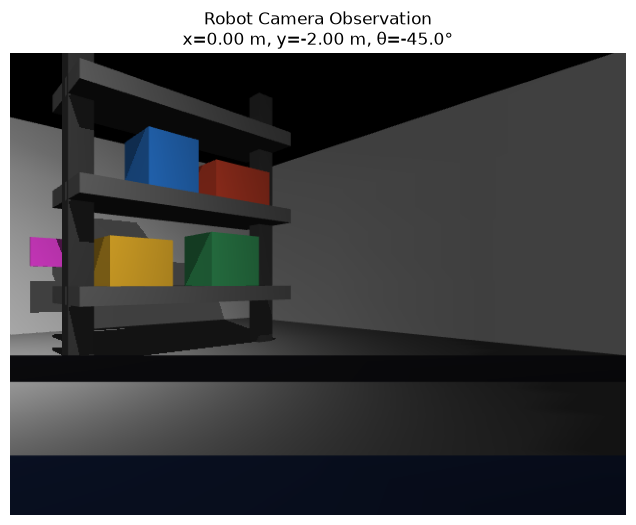

In [17]:
plt.figure(figsize=(8, 6))

plt.imshow(image)
plt.axis("off")

plt.title(
    f"Robot Camera Observation\n"
    f"x={sample['x']:.2f} m, "
    f"y={sample['y']:.2f} m, "
    f"θ={sample['theta_deg']:.1f}°"
)

plt.show()

## A2. What Changes When the Robot Position Changes?

To understand visual motion, we will first change **position** while
keeping orientation fixed.

We choose:

$$
\theta = 0^\circ
$$

and compare observations from different positions.

This isolates the effect of translational motion.

For example:

$$
(x,y,\theta)
=
(0.0,-2.0,0^\circ)
$$

versus

$$
(0.5,-2.0,0^\circ)
$$

versus

$$
(1.0,-2.0,0^\circ)
$$

The robot orientation remains unchanged, but the camera viewpoint
changes because the robot has moved.

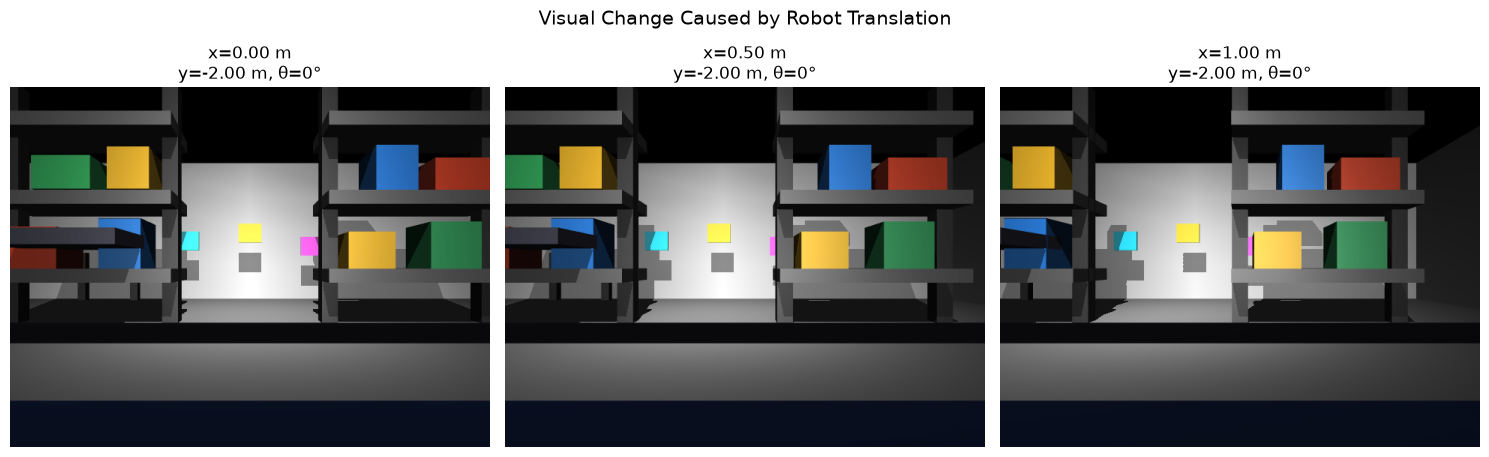

In [19]:
position_samples = metadata[
    (metadata["y"] == -2.0) &
    (metadata["theta_deg"] == 0.0) &
    (metadata["x"].isin([0.0, 0.5, 1.0]))
].sort_values("x")

fig, axes = plt.subplots(
    1,
    len(position_samples),
    figsize=(15, 5)
)

for ax, (_, row) in zip(axes, position_samples.iterrows()):

    image = load_image(row["image_filename"])

    ax.imshow(image)
    ax.axis("off")

    ax.set_title(
        f"x={row['x']:.2f} m\n"
        f"y={row['y']:.2f} m, "
        f"θ={row['theta_deg']:.0f}°"
    )

plt.suptitle(
    "Visual Change Caused by Robot Translation",
    fontsize=14
)

plt.tight_layout()
plt.show()

## A3. What Changes When the Robot Orientation Changes?

Now we keep the robot position fixed:

$$
x=0.5,\qquad y=-2.0
$$

and change only the orientation.

We compare:

$$
\theta=-30^\circ,\quad
0^\circ,\quad
30^\circ
$$

This isolates the visual effect of robot rotation.

The same physical environment is being observed, but from different
camera orientations.

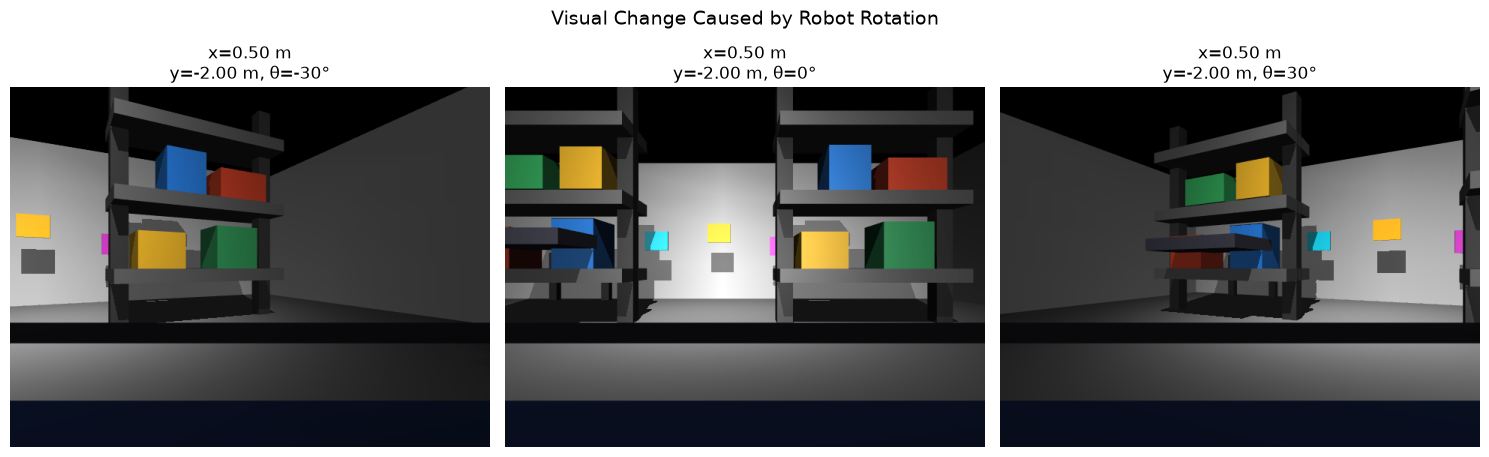

In [20]:
orientation_samples = metadata[
    (metadata["x"] == 0.5) &
    (metadata["y"] == -2.0) &
    (metadata["theta_deg"].isin([-30.0, 0.0, 30.0]))
].sort_values("theta_deg")

fig, axes = plt.subplots(
    1,
    len(orientation_samples),
    figsize=(15, 5)
)

for ax, (_, row) in zip(axes, orientation_samples.iterrows()):

    image = load_image(row["image_filename"])

    ax.imshow(image)
    ax.axis("off")

    ax.set_title(
        f"x={row['x']:.2f} m\n"
        f"y={row['y']:.2f} m, "
        f"θ={row['theta_deg']:.0f}°"
    )

plt.suptitle(
    "Visual Change Caused by Robot Rotation",
    fontsize=14
)

plt.tight_layout()
plt.show()

## A4. Are the Images Identical?

Although the warehouse environment is unchanged, the camera images
change when the robot moves.

We can quantify this using a simple image difference.

For two RGB images $I_1$ and $I_2$, define the mean absolute
difference as:

$$
D =
\frac{1}{N}
\sum_{i=1}^{N}
|I_1(i)-I_2(i)|
$$

A larger value indicates greater pixel-level change.

### Important limitation

Pixel difference alone is **not** a reliable motion estimator.

Changes in lighting, viewpoint, shadows, or object appearance can
produce pixel differences even when the robot motion is small.

Later we will therefore move from raw pixels to more meaningful visual
representations.

In [21]:
def mean_absolute_image_difference(image1, image2):
    """
    Compute the mean absolute pixel difference
    between two RGB images.
    """
    
    image1 = image1.astype(np.float32)
    image2 = image2.astype(np.float32)

    difference = np.abs(image1 - image2)

    return difference.mean()

In [22]:
row_a = position_samples.iloc[0]
row_b = position_samples.iloc[1]

image_a = load_image(row_a["image_filename"])
image_b = load_image(row_b["image_filename"])

difference = mean_absolute_image_difference(
    image_a,
    image_b
)

print(
    f"Mean absolute image difference: {difference:.2f}"
)

Mean absolute image difference: 24.90


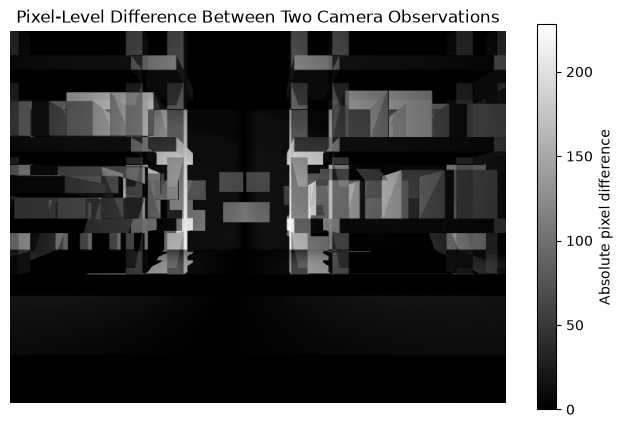

In [23]:
difference_image = np.abs(
    image_a.astype(np.float32) -
    image_b.astype(np.float32)
)

difference_image = difference_image.mean(axis=2)

plt.figure(figsize=(8, 5))

plt.imshow(
    difference_image,
    cmap="gray"
)

plt.colorbar(label="Absolute pixel difference")

plt.title(
    "Pixel-Level Difference Between Two Camera Observations"
)

plt.axis("off")
plt.show()

## Engineering Observation

From the experiments above, we can make four observations.

### Observation 1 — The environment is shared

The images contain many of the same physical structures because the
robot is observing the same warehouse.

### Observation 2 — Robot motion changes the image

Translation and rotation cause visible structures to move within the
camera image.

### Observation 3 — Raw pixels are not enough

A pixel at a particular image coordinate does not necessarily
correspond to the same physical point after the robot moves.

### Observation 4 — We need visual correspondences

To estimate motion, we need to identify visual information that
corresponds to the same physical structures across observations.

This leads to the next question:

> **How can we identify useful visual structures automatically?**

That is the role of visual feature extraction.

## Checkpoint 1 — Predict Before You Run

Consider the following two observations:

### Observation A

$$
(x,y,\theta)=(0.0,-2.0,0^\circ)
$$

### Observation B

$$
(x,y,\theta)=(0.5,-2.0,0^\circ)
$$

Answer the following before continuing:

1. Did the robot orientation change?

2. Did the camera viewpoint change?

3. Should some visual structures appear at different image locations?

4. Would a simple pixel-by-pixel comparison be sufficient to determine
   the robot's motion?

5. What type of information should a Visual SLAM system extract from
   the two images?

Write your answers in 3–5 sentences.

# Transition to Part B

We have now established the basic visual information available to the
robot.

The key observation is:

$$
\boxed{
\text{Robot Motion}
\rightarrow
\text{Change in Camera View}
}
$$

However, Visual SLAM cannot simply compare every pixel independently.

It needs to answer a more useful question:

> **Which visual structures in one image correspond to the same
> physical structures in another image?**

In the next part, we will build a classical visual baseline by
detecting and matching visual features.

This gives us a reference point before introducing learned CNN-based
representations.

# Part B — Establish a Visual Baseline

We now move from understanding the camera data to extracting motion
information from consecutive images.

Before introducing a CNN, we first establish a classical computer-vision
baseline.

The idea is simple:

$$
\boxed{
\text{Image}_t
\rightarrow
\text{Visual Features}
\rightarrow
\text{Feature Matching}
\rightarrow
\text{Relative Motion}
}
$$

If two consecutive images contain observations of the same physical
structures, their visual features can be matched.

The movement of these matched features provides information about how the
camera — and therefore the robot — has moved.

In this section we will:

1. detect visual features using ORB (Oriented FAST and Rotated BRIEF),
2. compute feature descriptors,
3. match features between consecutive images,
4. estimate relative image motion,
5. accumulate the motion into a trajectory.

This is our **classical visual baseline**.

Later, in Part C, we will replace the conventional visual representation
with a CNN-based representation and investigate what changes.

## B1. Detecting Visual Structure

A camera image contains thousands of pixels, but most pixels are not equally
useful for estimating motion.

For example:

- a large uniform wall contains little distinctive information;
- a rack corner is distinctive;
- an object boundary is distinctive;
- a textured surface may provide many useful observations.

We therefore extract a set of distinctive image locations called
**keypoints**.

For each keypoint, we also compute a numerical representation called a
**descriptor**.

Conceptually:

$$
\text{Image}
\rightarrow
\boxed{\text{Keypoints}}
+
\boxed{\text{Descriptors}}
$$

We will use ORB (Oriented FAST and Rotated BRIEF) as our classical
feature detector and descriptor.

In [24]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

DATASET_DIR = "data/dataset_v2"
IMAGE_DIR = os.path.join(DATASET_DIR, "images")

image_1_path = os.path.join(IMAGE_DIR, "frame_0001.png")
image_2_path = os.path.join(IMAGE_DIR, "frame_0002.png")

image_1 = cv2.imread(image_1_path)
image_2 = cv2.imread(image_2_path)

if image_1 is None or image_2 is None:
    raise FileNotFoundError(
        "Could not load one or both dataset images. "
        "Check the dataset_v2/images directory."
    )

image_1_rgb = cv2.cvtColor(image_1, cv2.COLOR_BGR2RGB)
image_2_rgb = cv2.cvtColor(image_2, cv2.COLOR_BGR2RGB)

print("Frame 1 shape:", image_1_rgb.shape)
print("Frame 2 shape:", image_2_rgb.shape)

Frame 1 shape: (480, 640, 3)
Frame 2 shape: (480, 640, 3)


## B2. Extract Visual Features

ORB identifies visually distinctive locations in the image.

For every detected keypoint, ORB produces:

- its image location,
- its scale,
- its orientation,
- a binary descriptor.

The descriptor allows us to compare a feature in one image with features
in another image.

The important distinction is:

$$
\boxed{\text{Keypoint} = \text{Where?}}
$$

$$
\boxed{\text{Descriptor} = \text{What does it look like?}}
$$

In [ ]:
orb = cv2.ORB_create(
    nfeatures=500
)

keypoints_1, descriptors_1 = orb.detectAndCompute(
    image_1,
    None
)

keypoints_2, descriptors_2 = orb.detectAndCompute(
    image_2,
    None
)

print("Keypoints in frame 1:", len(keypoints_1))
print("Keypoints in frame 2:", len(keypoints_2))

if descriptors_1 is None or descriptors_2 is None:
    raise RuntimeError(
        "ORB could not compute descriptors for one or both images."
    )

Keypoints in frame 1: 50
Keypoints in frame 2: 50


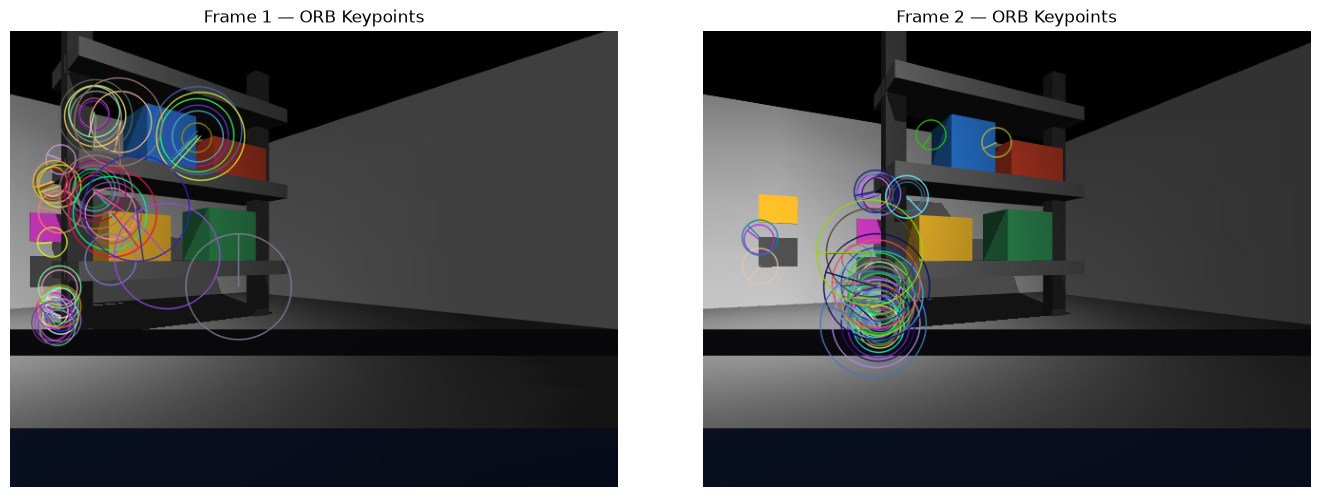

In [28]:
image_1_features = cv2.drawKeypoints(
    image_1_rgb,
    keypoints_1,
    None,
    flags=cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS
)

image_2_features = cv2.drawKeypoints(
    image_2_rgb,
    keypoints_2,
    None,
    flags=cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_1_features)
plt.title("Frame 1 — ORB Keypoints")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image_2_features)
plt.title("Frame 2 — ORB Keypoints")
plt.axis("off")

plt.tight_layout()
plt.show()

### Checkpoint B1 — Predict Before Continuing

Look at the detected keypoints.

1. Where are most of the keypoints concentrated?
2. Are keypoints distributed uniformly across the image?
3. Which warehouse structures produce many keypoints?
4. Why are large uniform regions less useful?
5. What do you expect to happen if we reduce `nfeatures` from 500 to 50?

Change:

```python
nfeatures=50

# B3. Match Features Between Frames

Detecting features independently is not enough.

We need to determine which feature in frame \(t\) corresponds to which
feature in frame \(t+1\).

Conceptually:

$$
f_i^{(t)}
\longleftrightarrow
f_j^{(t+1)}
$$

A good correspondence means that both image locations are likely to
represent the same physical structure.

We will use the ORB binary descriptors together with a
Brute-Force Hamming-distance matcher.

In [29]:
bf = cv2.BFMatcher(
    cv2.NORM_HAMMING,
    crossCheck=True
)

matches = bf.match(
    descriptors_1,
    descriptors_2
)

matches = sorted(
    matches,
    key=lambda m: m.distance
)

print("Total matches:", len(matches))

Total matches: 18


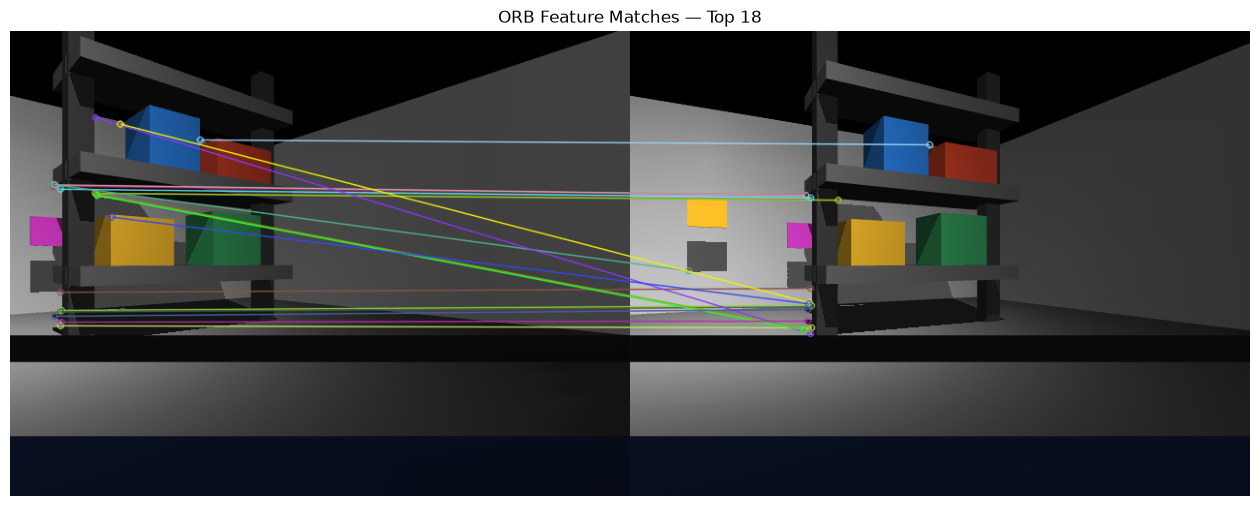

In [30]:
num_matches_to_display = min(50, len(matches))

match_image = cv2.drawMatches(
    image_1_rgb,
    keypoints_1,
    image_2_rgb,
    keypoints_2,
    matches[:num_matches_to_display],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(16, 7))
plt.imshow(match_image)
plt.title(f"ORB Feature Matches — Top {num_matches_to_display}")
plt.axis("off")
plt.show()

### Think About the Matches

Not every match is correct.

Some correspondences may be:

- correct matches,
- ambiguous matches,
- geometrically inconsistent matches,
- caused by visually similar objects.

Therefore:

$$
\boxed{
\text{Feature Matching}
\neq
\text{Perfect Correspondence}
}
$$

A Visual SLAM system must reject unreliable observations and retain
geometrically consistent correspondences.

This is one reason why visual perception is only one component of a SLAM
system.

## B4. Estimate Relative Visual Motion

The matched features provide pairs of image coordinates.

However, some matches may be incorrect.

We therefore estimate a geometric transformation while rejecting
inconsistent correspondences.

RANSAC is useful because it can estimate the transformation even when some
feature matches are outliers.

Conceptually:

$$
\text{Matches}
\rightarrow
\text{RANSAC}
\rightarrow
\text{Geometrically Consistent Matches}
$$

The resulting transformation describes how the image appearance changes
between the two observations.

### Important limitation

A 2-D image transformation is **not equivalent to a complete 3-D robot
pose estimate**.

We use it here as a controlled visual-motion baseline.

A complete monocular Visual SLAM system requires additional geometric
reasoning, depth/scale handling, state estimation, and map management.

In [31]:
# ============================================================
# B6 — RANSAC Geometric Verification
# ============================================================

# Extract matched keypoint coordinates
src_points = np.float32([
    keypoints_1[m.queryIdx].pt
    for m in matches
]).reshape(-1, 1, 2)

dst_points = np.float32([
    keypoints_2[m.trainIdx].pt
    for m in matches
]).reshape(-1, 1, 2)


# ------------------------------------------------------------
# Estimate homography using RANSAC
# ------------------------------------------------------------

if len(matches) < 4:
    raise RuntimeError(
        f"At least 4 matches are required for homography estimation. "
        f"Only {len(matches)} matches were found."
    )

H, mask = cv2.findHomography(
    src_points,
    dst_points,
    cv2.RANSAC,
    5.0
)


# ------------------------------------------------------------
# Check result
# ------------------------------------------------------------

if H is None or mask is None:
    raise RuntimeError(
        "RANSAC could not estimate a valid homography."
    )


# ------------------------------------------------------------
# Count inliers and outliers
# ------------------------------------------------------------

mask = mask.ravel()

num_inliers = int(np.sum(mask))
num_outliers = len(mask) - num_inliers

inlier_ratio = num_inliers / len(mask)


print("========== RANSAC RESULT ==========")
print(f"Total matches : {len(matches)}")
print(f"Inliers       : {num_inliers}")
print(f"Outliers      : {num_outliers}")
print(f"Inlier ratio  : {inlier_ratio:.3f}")

print()
print("Estimated homography:")
print(H)

========== RANSAC RESULT ==========
Total matches : 18
Inliers       : 11
Outliers      : 7
Inlier ratio  : 0.611

Estimated homography:
[[-1.09293040e-01 -2.73485369e-01  1.64609028e+02]
 [-4.83172480e-01  1.31788142e-01  1.09142740e+02]
 [-2.78033192e-03 -1.47486719e-03  1.00000000e+00]]


### Visualizing Geometrically Consistent Matches

RANSAC separates the feature matches into two groups:

- **Inliers** — matches that are consistent with the estimated geometric transformation.
- **Outliers** — matches that do not agree with the transformation.

This is important because feature matching alone does not guarantee that
two image points correspond to the same physical structure.

We therefore move from:

$$
\text{Visual Similarity}
$$

to:

$$
\text{Visual Similarity}
+
\text{Geometric Consistency}
$$

The inlier matches are the observations that provide stronger evidence about
the relative visual motion between the two frames.

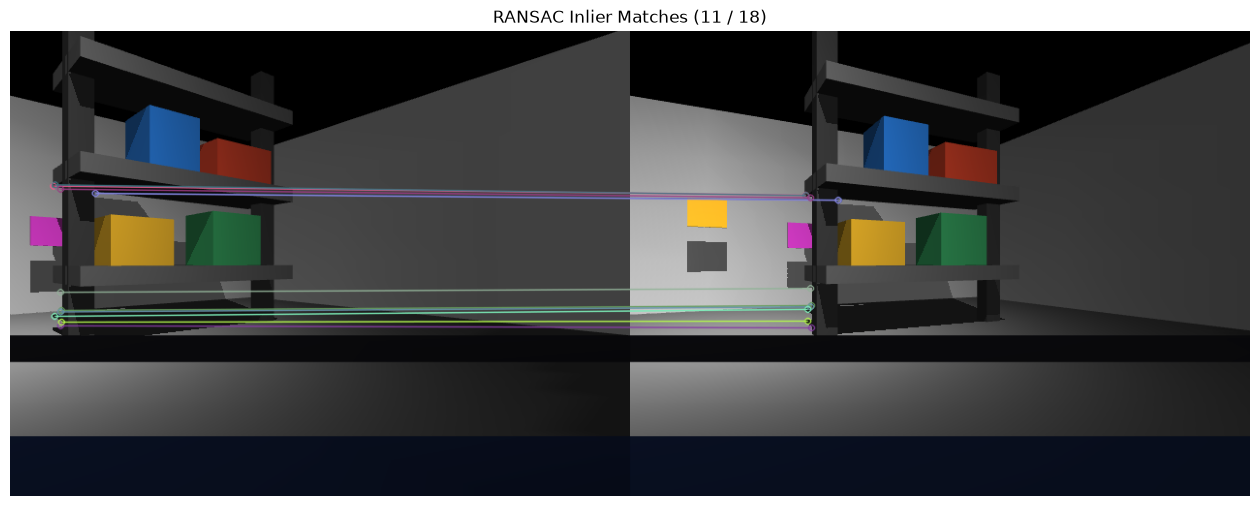

In [33]:
# ============================================================
# Visualize RANSAC inliers
# ============================================================

inlier_matches = [
    m for i, m in enumerate(matches)
    if mask[i] == 1
]

num_inliers_to_display = min(
    50,
    len(inlier_matches)
)

inlier_match_image = cv2.drawMatches(
    image_1_rgb,
    keypoints_1,
    image_2_rgb,
    keypoints_2,
    inlier_matches[:num_inliers_to_display],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)


plt.figure(figsize=(16, 7))

plt.imshow(inlier_match_image)

plt.title(
    f"RANSAC Inlier Matches "
    f"({num_inliers} / {len(matches)})"
)

plt.axis("off")
plt.show()

### Inliers vs Outliers

The previous visualization shows only the geometrically consistent
correspondences.

Now we compare the original matches with the RANSAC inliers.

A large number of incorrect matches would make direct motion estimation
unreliable.

RANSAC attempts to identify a transformation supported by the largest
consistent subset of observations.

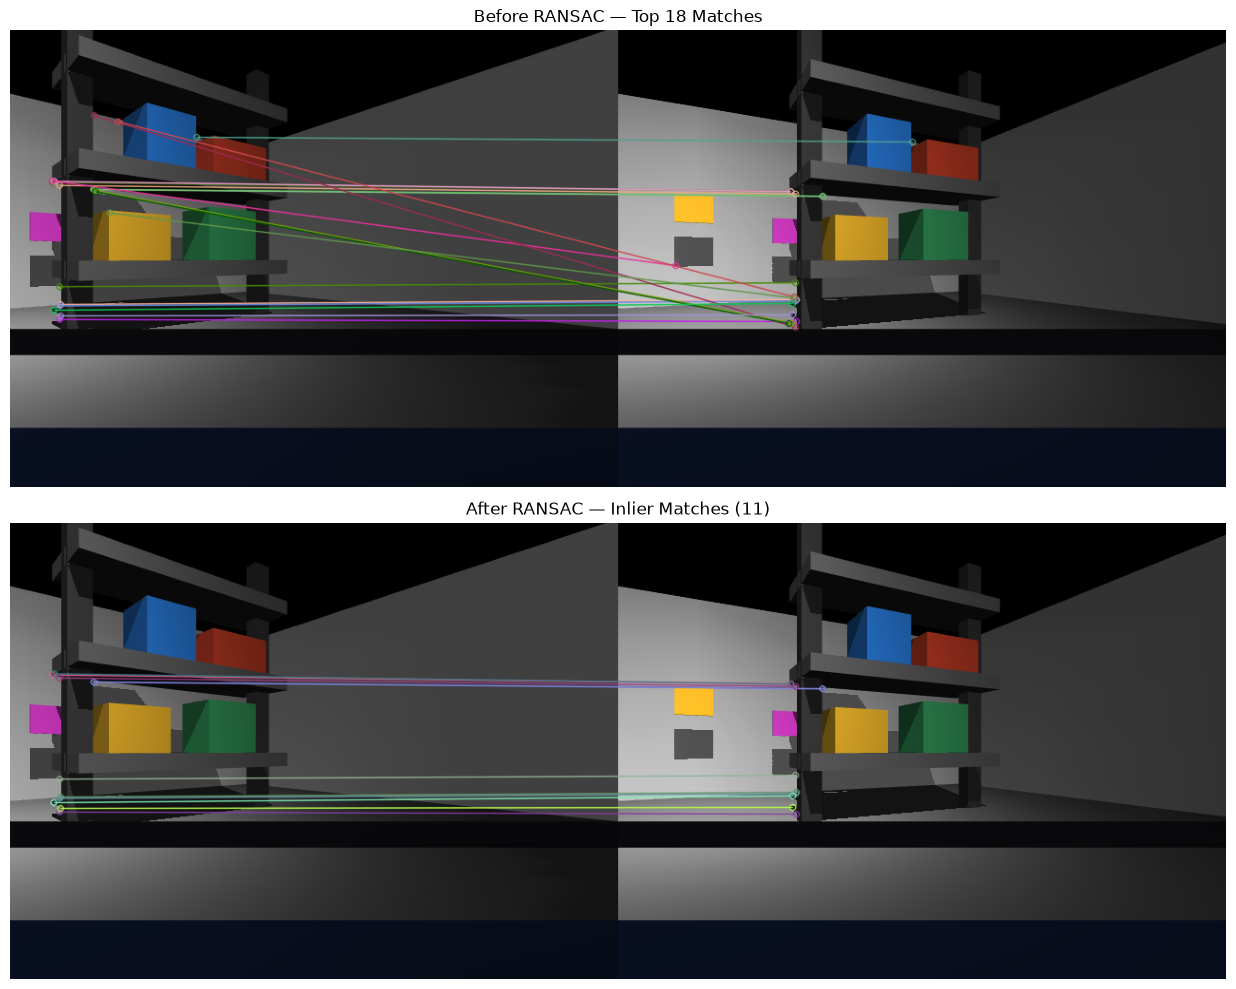

In [34]:
# ============================================================
# Compare all matches and RANSAC inliers
# ============================================================

plt.figure(figsize=(16, 10))

plt.subplot(2, 1, 1)

all_match_image = cv2.drawMatches(
    image_1_rgb,
    keypoints_1,
    image_2_rgb,
    keypoints_2,
    matches[:num_matches_to_display],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.imshow(all_match_image)
plt.title(
    f"Before RANSAC — Top {num_matches_to_display} Matches"
)
plt.axis("off")


plt.subplot(2, 1, 2)

plt.imshow(inlier_match_image)
plt.title(
    f"After RANSAC — Inlier Matches ({num_inliers})"
)
plt.axis("off")

plt.tight_layout()
plt.show()

## Checkpoint B5 — Effect of the RANSAC Threshold
The RANSAC threshold controls how much geometric error is tolerated when
deciding whether a feature match is an inlier.

The current implementation uses:

```python
5.0
as the reprojection-error threshold.

## Experiment
Repeat the RANSAC estimation using:
- 2.0
- 5.0
- 10.0
Before running the experiment, predict:
1. What will happen to the number of inliers when the threshold is reduced?
2. What will happen when the threshold is increased?
3. Which threshold appears to give a more reliable set of correspondences?

Record the observed:
RANSAC threshold	Number of inliers	Inlier ratio
2.0		
5.0		
10.0		



## Engineering observation
A larger number of inliers is not automatically better.
A very large threshold may accept geometrically inconsistent matches,
while an excessively small threshold may reject valid matches.
Therefore, the parameter must balance:
$$
\boxed{
\text{Match acceptance}
\quad \text{vs.} \quad
\text{Geometric consistency}
}
$$

## B6. Estimate Relative Camera Motion

We have now established that feature matches alone are not sufficient.

After RANSAC, we have a set of geometrically consistent correspondences between two images.

The next question is:

> Can these correspondences tell us how the camera moved?

For a calibrated camera, the relationship between corresponding image points can be described using the **Essential Matrix**.

Conceptually:

$$
\text{Matched Features}
\rightarrow
\text{Essential Matrix}
\rightarrow
\text{Relative Camera Pose}
$$

The relative pose contains:

- **Rotation** — how the camera orientation changed
- **Translation direction** — the direction in which the camera moved

For a monocular camera, the absolute scale of translation cannot be recovered from two images alone.

Therefore, the recovered translation vector should be interpreted as a **direction**, not as a metric displacement in metres.

### Important distinction

Our previous homography experiment answered:

> "Which image correspondences are geometrically consistent?"

The Essential Matrix now addresses:

> "What relative 3-D camera motion is consistent with those observations?"

This is an important step toward visual odometry.

### Camera Calibration

A real visual-odometry system requires the camera intrinsic parameters.

For this laboratory, we use an approximate intrinsic matrix for the simulated $640\times480$ camera:

$$
K =
\begin{bmatrix}
f_x & 0 & c_x\\
0 & f_y & c_y\\
0 & 0 & 1
\end{bmatrix}
$$

where the principal point is approximated as the image centre.

This approximation is sufficient for demonstrating the relative-pose estimation pipeline. It should not be interpreted as a calibrated camera model for a physical robot.

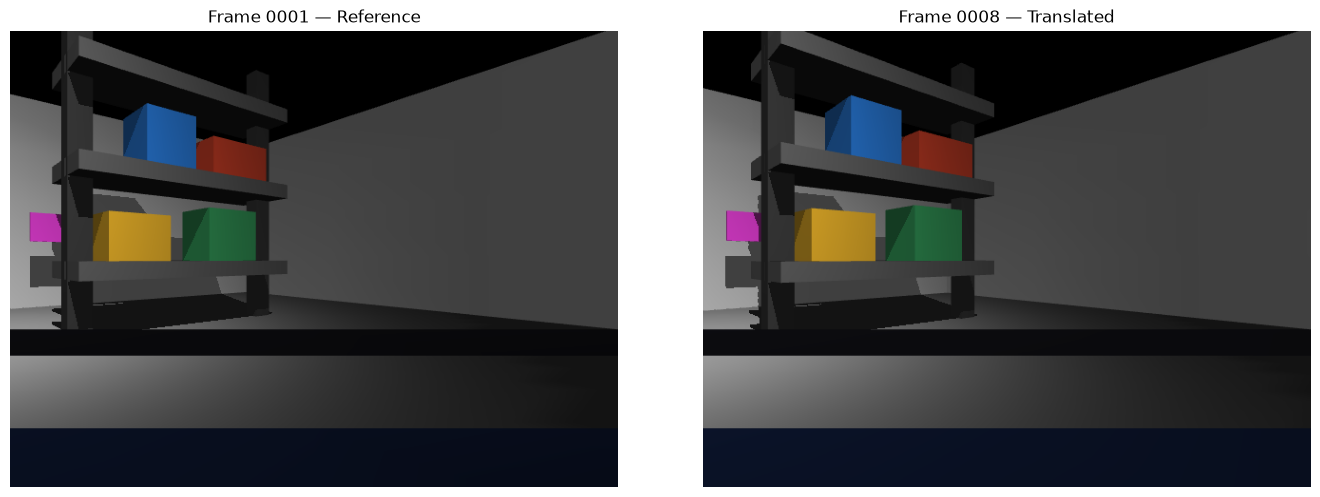

In [35]:
# ============================================================
# B6 — Select a controlled image pair for relative motion
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


DATASET_DIR = "data/dataset_v2"
IMAGE_DIR = os.path.join(DATASET_DIR, "images")


# ------------------------------------------------------------
# Use a controlled translation pair
#
# frame_0001 : x=0.00, y=-2.00, theta=-45°
# frame_0008 : x=0.25, y=-2.00, theta=-45°
#
# The robot orientation remains constant while x changes.
# ------------------------------------------------------------

image_1_path = os.path.join(
    IMAGE_DIR,
    "frame_0001.png"
)

image_2_path = os.path.join(
    IMAGE_DIR,
    "frame_0008.png"
)


image_1 = cv2.imread(image_1_path)
image_2 = cv2.imread(image_2_path)


if image_1 is None or image_2 is None:
    raise FileNotFoundError(
        "Could not load the selected image pair."
    )


image_1_rgb = cv2.cvtColor(
    image_1,
    cv2.COLOR_BGR2RGB
)

image_2_rgb = cv2.cvtColor(
    image_2,
    cv2.COLOR_BGR2RGB
)


plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_1_rgb)
plt.title("Frame 0001 — Reference")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image_2_rgb)
plt.title("Frame 0008 — Translated")
plt.axis("off")

plt.tight_layout()
plt.show()

In [36]:
# ============================================================
# Extract ORB features and match the selected image pair
# ============================================================

orb = cv2.ORB_create(
    nfeatures=500
)


keypoints_1, descriptors_1 = orb.detectAndCompute(
    image_1,
    None
)

keypoints_2, descriptors_2 = orb.detectAndCompute(
    image_2,
    None
)


if descriptors_1 is None or descriptors_2 is None:
    raise RuntimeError(
        "Could not compute ORB descriptors."
    )


# ------------------------------------------------------------
# Match binary ORB descriptors using Hamming distance
# ------------------------------------------------------------

matcher = cv2.BFMatcher(
    cv2.NORM_HAMMING,
    crossCheck=True
)


matches = matcher.match(
    descriptors_1,
    descriptors_2
)


matches = sorted(
    matches,
    key=lambda m: m.distance
)


print("Keypoints in frame 1 :", len(keypoints_1))
print("Keypoints in frame 2 :", len(keypoints_2))
print("Total matches        :", len(matches))


if len(matches) < 8:
    raise RuntimeError(
        "At least 8 matches are recommended for essential-matrix estimation."
    )

Keypoints in frame 1 : 414
Keypoints in frame 2 : 438
Total matches        : 265


In [37]:
# ============================================================
# Estimate Essential Matrix
# ============================================================

# ------------------------------------------------------------
# Image dimensions
# ------------------------------------------------------------

height, width = image_1.shape[:2]


# ------------------------------------------------------------
# Approximate camera intrinsics
#
# This is a teaching approximation for the simulated camera.
# ------------------------------------------------------------

fx = 640.0
fy = 640.0

cx = width / 2.0
cy = height / 2.0


K = np.array([
    [fx, 0.0, cx],
    [0.0, fy, cy],
    [0.0, 0.0, 1.0]
])


# ------------------------------------------------------------
# Extract matched point coordinates
# ------------------------------------------------------------

points_1 = np.float32([
    keypoints_1[m.queryIdx].pt
    for m in matches
])

points_2 = np.float32([
    keypoints_2[m.trainIdx].pt
    for m in matches
])


# ------------------------------------------------------------
# Estimate Essential Matrix using RANSAC
# ------------------------------------------------------------

E, essential_mask = cv2.findEssentialMat(
    points_1,
    points_2,
    K,
    method=cv2.RANSAC,
    prob=0.999,
    threshold=1.0
)


if E is None:
    raise RuntimeError(
        "Essential Matrix estimation failed."
    )


essential_inliers = int(
    essential_mask.sum()
)


print("========== ESSENTIAL MATRIX ==========")
print(E)

print()
print("Total correspondences :", len(matches))
print("Essential inliers     :", essential_inliers)
print(
    "Inlier ratio           :",
    f"{essential_inliers / len(matches):.3f}"
)

========== ESSENTIAL MATRIX ==========
[[ 2.72607850e-05 -6.18740527e-01 -4.07170593e-03]
 [ 6.18150917e-01  1.78797954e-04  3.43322614e-01]
 [ 4.36925359e-03 -3.42262265e-01  1.66007931e-04]]

Total correspondences : 265
Essential inliers     : 196
Inlier ratio           : 0.740


In [38]:
# ============================================================
# Recover Relative Camera Pose
# ============================================================

_, R, t, pose_mask = cv2.recoverPose(
    E,
    points_1,
    points_2,
    K
)


pose_inliers = int(
    pose_mask.sum()
)


print("========== RELATIVE CAMERA POSE ==========")

print("\nRotation matrix R:")
print(R)

print("\nTranslation direction t:")
print(t)

print()
print("Pose inliers:", pose_inliers)


# ------------------------------------------------------------
# Convert rotation matrix to rotation angle
# ------------------------------------------------------------

rotation_trace = np.trace(R)

cos_angle = (
    rotation_trace - 1.0
) / 2.0

cos_angle = np.clip(
    cos_angle,
    -1.0,
    1.0
)

rotation_angle_deg = np.degrees(
    np.arccos(cos_angle)
)


print(
    "\nEstimated rotation angle:",
    f"{rotation_angle_deg:.2f} degrees"
)


# ------------------------------------------------------------
# Normalize translation for display
# ------------------------------------------------------------

translation_direction = (
    t.flatten()
    / np.linalg.norm(t)
)


print(
    "\nNormalized translation direction:"
)

print(translation_direction)

========== RELATIVE CAMERA POSE ==========

Rotation matrix R:
[[ 9.99998530e-01  3.27772001e-05  1.71430920e-03]
 [-3.19831732e-05  9.99999892e-01 -4.63201374e-04]
 [-1.71432420e-03  4.63145864e-04  9.99998423e-01]]

Translation direction t:
[[ 0.48403219]
 [ 0.00616359]
 [-0.87502848]]

Pose inliers: 66555

Estimated rotation angle: 0.10 degrees

Normalized translation direction:
[ 0.48403219  0.00616359 -0.87502848]


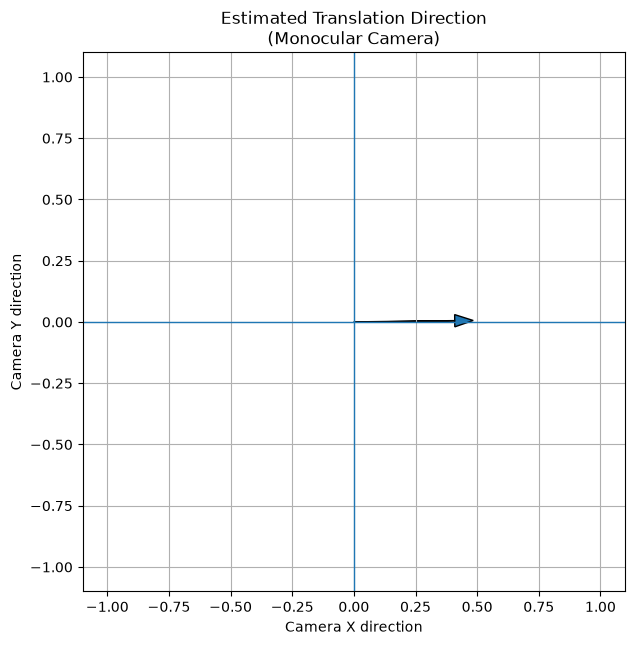

In [39]:
# ============================================================
# Visualize the estimated translation direction
# ============================================================

tx, ty, tz = translation_direction


plt.figure(figsize=(7, 7))

plt.axhline(
    0,
    linewidth=1
)

plt.axvline(
    0,
    linewidth=1
)


plt.arrow(
    0,
    0,
    tx,
    ty,
    head_width=0.05,
    length_includes_head=True
)


plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)

plt.xlabel("Camera X direction")
plt.ylabel("Camera Y direction")

plt.title(
    "Estimated Translation Direction\n"
    "(Monocular Camera)"
)

plt.grid(True)

plt.show()

## Engineering Observation

The relative-pose estimation provides two important pieces of information:

### 1. Rotation

The rotation matrix $R$ describes how the camera orientation changed between the two observations.

### 2. Translation direction

The translation vector $t$ indicates the direction of camera motion.

However, its magnitude is unknown.

Therefore:

$$
\boxed{
\text{Monocular Visual Odometry}
\Rightarrow
\text{Relative Motion}
+
\text{Unknown Scale}
}
$$

This is known as the **scale ambiguity** of monocular vision.

For a real warehouse AMR, this limitation is important.

The robot already has:

- wheel encoders
- IMU
- LiDAR

These sensors can provide complementary information that can help resolve motion ambiguity and improve robustness.

This is one reason practical mobile robots rarely depend on a single sensing modality.

## Checkpoint B6 — Relative Motion

Consider the following result:

- The Essential Matrix was successfully estimated.
- The recovered rotation is close to zero.
- The translation direction is non-zero.

Answer the following:

1. Why can the system estimate the direction of translation but not its absolute magnitude?

2. If the robot moves twice as far between the two images, can monocular vision alone determine that the distance was exactly twice as large?

3. Why would wheel odometry be useful together with monocular visual odometry?

4. What would you expect to happen if the two images contained very few reliable feature correspondences?

5. Is the recovered translation vector expressed directly in metres?

**Expected reasoning:**  
No. The translation is determined only up to an unknown scale factor.

# Part C — CNN-Based Visual Representation

The classical pipeline in Part B relied on hand-crafted ORB features.

This works, but the features are designed using manually engineered rules.

A CNN learns visual representations directly from image data.

For visual SLAM, learned visual features can provide a more expressive representation of the scene.

The basic idea is:

Image
→ CNN
→ Learned feature representation
→ Compare / match visual observations

In a complete neural visual-SLAM system, CNNs may support:

- robust feature extraction
- visual odometry
- depth estimation
- loop-closure detection
- semantic understanding

In this laboratory, we will focus on the first step:

> **Using a pretrained CNN to obtain a learned visual representation of the warehouse scene.**
> **ResNet18 is appropriate here: simple, established, and fast enough for the lab**

We will then compare this representation with the classical feature-based approach from Part B.

In [48]:
# ============================================================
# C2 — Load a pretrained CNN
# ============================================================

import torch
import torchvision
import torchvision.transforms as transforms

from PIL import Image


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# ------------------------------------------------------------
# Load pretrained ResNet18
# ------------------------------------------------------------

weights = torchvision.models.ResNet18_Weights.DEFAULT

cnn = torchvision.models.resnet18(
    weights=weights
)

cnn = cnn.to(device)
cnn.eval()


# ------------------------------------------------------------
# Image preprocessing supplied with the pretrained model
# ------------------------------------------------------------

transform = weights.transforms()

print("CNN loaded successfully.")

Device: cpu
CNN loaded successfully.


### Why ResNet?
Add a short Markdown explanation immediately before the ResNet code:
- ResNet is a CNN architecture trained on large-scale image datasets.
- We use a pretrained ResNet as a feature extractor, not as a classifier.
- The final classification layer is removed.
- The remaining network converts an image into a numerical feature vector.
- Visually similar images should ideally produce similar feature vectors.

In [49]:
# ============================================================
# C3 — Extract a learned visual representation
# ============================================================

# ------------------------------------------------------------
# Remove the final classification layer.
#
# The remaining network produces a visual embedding.
# ------------------------------------------------------------

feature_extractor = torch.nn.Sequential(
    *list(cnn.children())[:-1]
)

feature_extractor = feature_extractor.to(device)
feature_extractor.eval()


def extract_cnn_feature(image_path):

    image = Image.open(image_path).convert("RGB")

    tensor = transform(image).unsqueeze(0)
    tensor = tensor.to(device)

    with torch.no_grad():

        feature = feature_extractor(
            tensor
        )

    feature = feature.flatten(
        start_dim=1
    )

    feature = feature.cpu().numpy()[0]

    return feature

### Feature Extraction
The feature extraction process converts each image from pixel space into a compact numerical representation. This representation captures higher-level visual characteristics such as shapes, structures, and appearance rather than individual pixel values.

In [50]:
# ============================================================
# Test CNN feature extraction
# ============================================================

feature_1 = extract_cnn_feature(
    image_1_path
)

feature_2 = extract_cnn_feature(
    image_2_path
)


print("Feature 1 shape:", feature_1.shape)
print("Feature 2 shape:", feature_2.shape)

Feature 1 shape: (512,)
Feature 2 shape: (512,)


### Cosine Similarity
Two images can be compared by measuring the similarity between their feature vectors. Cosine similarity measures the angle between two vectors and is commonly used for comparing learned visual representations.

In [51]:
# ============================================================
# C4 — Compare CNN visual representations
# ============================================================

from scipy.spatial.distance import cosine


cnn_distance = cosine(
    feature_1,
    feature_2
)

cnn_similarity = 1.0 - cnn_distance


print("========== CNN FEATURE COMPARISON ==========")

print(
    f"Cosine distance : {cnn_distance:.4f}"
)

print(
    f"Cosine similarity: {cnn_similarity:.4f}"
)

========== CNN FEATURE COMPARISON ==========
Cosine distance : 0.0197
Cosine similarity: 0.9803


In [52]:
# ============================================================
# Compare with another warehouse view
# ============================================================

different_image_path = os.path.join(
    IMAGE_DIR,
    "frame_0175.png"
)

feature_3 = extract_cnn_feature(
    different_image_path
)


distance_13 = cosine(
    feature_1,
    feature_3
)

similarity_13 = 1.0 - distance_13


print("Similarity: frame 0001 vs frame 0175")
print(
    f"Cosine similarity: {similarity_13:.4f}"
)

Similarity: frame 0001 vs frame 0175
Cosine similarity: 0.8892


## Engineering Observation

The CNN does not explicitly identify:

- corners
- edges
- ORB keypoints
- descriptor distances

Instead, the pretrained network transforms the image into a learned feature representation.

This gives us a different visual-processing strategy:

### Classical approach

Image
→ Hand-crafted features
→ Descriptor matching
→ Geometric verification
→ Motion estimation

### CNN-based approach

Image
→ Learned visual representation
→ Feature similarity / learned correspondence
→ Higher-level visual processing

The CNN representation can therefore become another component of a visual-SLAM system.

However, a CNN embedding by itself is **not SLAM**.

SLAM still requires reasoning about:

- camera/robot motion
- spatial relationships
- map representation
- accumulated trajectory
- uncertainty
- loop closure

The CNN provides visual information that can support these components.

## Classical Approach (Part-B) vs CNN Based Approach (Part-c)

| Classical B | CNN C |
|---|---|
| ORB | ResNet18 |
| Hand-crafted features | Learned representation |
| Keypoint descriptors | CNN embedding |
| Explicit matching | Feature similarity |
| Geometry gives motion | CNN provides visual representation |
| Interpretable pipeline | More expressive learned representation |


# Part D — Integrating Visual Features into a SLAM Pipeline

We now combine the components developed in Parts B and C.

In Part B, we used conventional visual features and geometric methods to estimate relative camera motion.

In Part C, we introduced a CNN-based visual representation and used feature similarity to compare images.

We now combine these ideas into a simplified CNN-assisted Visual SLAM pipeline:

$$
\boxed{
\text{Camera Images}
\rightarrow
\text{CNN Similarity}
\rightarrow
\text{Visual Correspondence}
\rightarrow
\text{Geometric Motion}
\rightarrow
\text{Trajectory}
}
$$

The important engineering idea is that the CNN and geometric vision components perform different roles:

- **CNN features** provide a learned representation of visual appearance.
- **Visual matching** identifies corresponding image observations.
- **RANSAC + Essential Matrix** estimate geometrically consistent camera motion.
- **Motion accumulation** produces an estimated camera trajectory.

### Important

The CNN feature embedding used in this laboratory does **not** directly estimate robot pose.

Instead, it provides visual information that can support the perception stage of the SLAM pipeline.

The final motion estimate still requires geometric reasoning.

## D2. Define a Controlled Robot Motion Sequence

The dataset contains controlled robot poses rather than a naturally recorded trajectory.

Therefore, we explicitly select a sequence of poses that represents a simple robot motion.

We first move along the X direction:

$$
(0,-2,0)
\rightarrow
(0.25,-2,0)
\rightarrow
(0.5,-2,0)
\rightarrow
(0.75,-2,0)
\rightarrow
(1,-2,0)
$$

Then we move along the Y direction:

$$
(1,-2,0)
\rightarrow
(1,-1.75,0)
\rightarrow
(1,-1.5,0)
\rightarrow
(1,-1.25,0)
\rightarrow
(1,-1,0)
$$

This gives us a controlled L-shaped reference path.

The ground-truth poses are used only for comparison. The estimated trajectory is generated from visual observations.

In [56]:
# ============================================================
# D2 — Select a controlled visual sequence
# ============================================================

sequence_poses = [
    (0.00, -2.00, 0.0),
    (0.25, -2.00, 0.0),
    (0.50, -2.00, 0.0),
    (0.75, -2.00, 0.0),
    (1.00, -2.00, 0.0),

    (1.00, -1.75, 0.0),
    (1.00, -1.50, 0.0),
    (1.00, -1.25, 0.0),
    (1.00, -1.00, 0.0),
]


sequence_rows = []

for x, y, theta in sequence_poses:

    matches = metadata[
        np.isclose(metadata["x"], x) &
        np.isclose(metadata["y"], y) &
        np.isclose(metadata["theta_deg"], theta)
    ]

    if len(matches) != 1:
        raise ValueError(
            f"Pose not uniquely found: "
            f"x={x}, y={y}, theta={theta}"
        )

    sequence_rows.append(matches.iloc[0])


print("========== SELECTED VISUAL SEQUENCE ==========")

for i, row in enumerate(sequence_rows, start=1):

    print(
        f"{i:02d}: "
        f"{row['image_filename']} | "
        f"x={row['x']:.2f}, "
        f"y={row['y']:.2f}, "
        f"theta={row['theta_deg']:.1f}°"
    )

========== SELECTED VISUAL SEQUENCE ==========
01: frame_0004.png | x=0.00, y=-2.00, theta=0.0°
02: frame_0039.png | x=0.25, y=-2.00, theta=0.0°
03: frame_0074.png | x=0.50, y=-2.00, theta=0.0°
04: frame_0109.png | x=0.75, y=-2.00, theta=0.0°
05: frame_0144.png | x=1.00, y=-2.00, theta=0.0°
06: frame_0151.png | x=1.00, y=-1.75, theta=0.0°
07: frame_0158.png | x=1.00, y=-1.50, theta=0.0°
08: frame_0165.png | x=1.00, y=-1.25, theta=0.0°
09: frame_0172.png | x=1.00, y=-1.00, theta=0.0°


## D3. CNN-Based Visual Continuity

Before estimating geometric motion, we first examine whether consecutive observations are visually similar.

The CNN embedding provides a compact representation of the image.

For two images with feature vectors $f_i$ and $f_j$, cosine similarity is:

$$
\text{sim}(f_i,f_j)
=
\frac{f_i^T f_j}
{\|f_i\|\|f_j\|}
$$

A higher value indicates that the two images have more similar learned visual representations.

This does not provide the geometric transformation between the images.

Instead, it answers a simpler question:

> **Do these two observations appear to represent visually similar scenes?**

This is useful as a perception-level consistency check before geometric motion estimation.

In [57]:
# ============================================================
# D3 — CNN-Based Visual Continuity
# ============================================================

from scipy.spatial.distance import cosine


cnn_similarities = []


print("========== CNN VISUAL CONTINUITY ==========")


for i in range(len(sequence_rows) - 1):

    row_1 = sequence_rows[i]
    row_2 = sequence_rows[i + 1]

    image_path_1 = os.path.join(
        IMAGE_DIR,
        row_1["image_filename"]
    )

    image_path_2 = os.path.join(
        IMAGE_DIR,
        row_2["image_filename"]
    )

    # --------------------------------------------------------
    # Extract CNN representations
    # Reuse the function already created in Part C.
    # --------------------------------------------------------

    feature_1 = extract_cnn_feature(
        image_path_1
    )

    feature_2 = extract_cnn_feature(
        image_path_2
    )

    # --------------------------------------------------------
    # Cosine similarity
    # cosine() returns distance.
    # similarity = 1 - distance
    # --------------------------------------------------------

    cosine_distance = cosine(
        feature_1,
        feature_2
    )

    similarity = 1.0 - cosine_distance

    cnn_similarities.append(
        similarity
    )

    print(
        f"Pair {i+1}: "
        f"{row_1['image_filename']} → "
        f"{row_2['image_filename']} | "
        f"Cosine similarity = {similarity:.4f}"
    )


print()
print(
    "Average CNN similarity:",
    f"{np.mean(cnn_similarities):.4f}"
)

========== CNN VISUAL CONTINUITY ==========
Pair 1: frame_0004.png → frame_0039.png | Cosine similarity = 0.9762
Pair 2: frame_0039.png → frame_0074.png | Cosine similarity = 0.9643
Pair 3: frame_0074.png → frame_0109.png | Cosine similarity = 0.9663
Pair 4: frame_0109.png → frame_0144.png | Cosine similarity = 0.9606
Pair 5: frame_0144.png → frame_0151.png | Cosine similarity = 0.9758
Pair 6: frame_0151.png → frame_0158.png | Cosine similarity = 0.9747
Pair 7: frame_0158.png → frame_0165.png | Cosine similarity = 0.9773
Pair 8: frame_0165.png → frame_0172.png | Cosine similarity = 0.9800

Average CNN similarity: 0.9719


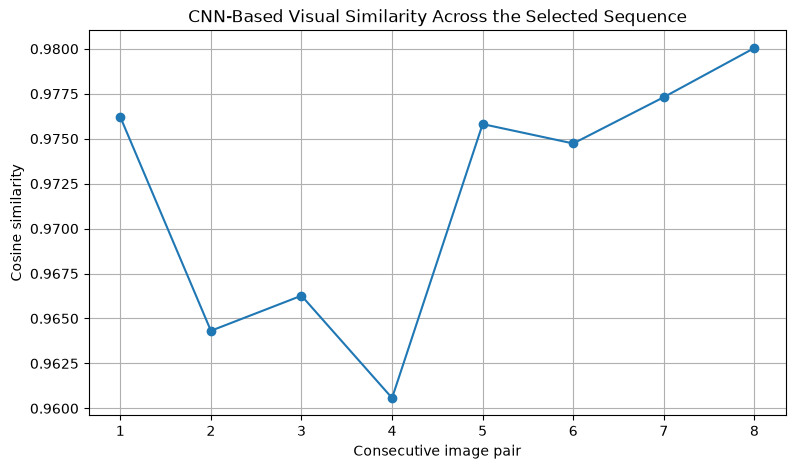

In [58]:
# ============================================================
# Visualize CNN similarity between consecutive observations
# ============================================================

pair_numbers = np.arange(
    1,
    len(cnn_similarities) + 1
)


plt.figure(figsize=(9, 5))

plt.plot(
    pair_numbers,
    cnn_similarities,
    marker="o"
)

plt.xlabel("Consecutive image pair")
plt.ylabel("Cosine similarity")

plt.title(
    "CNN-Based Visual Similarity Across the Selected Sequence"
)

plt.grid(True)

plt.show()

## D4. Geometric Motion Estimation

CNN similarity tells us whether two observations have similar learned visual representations.

It does **not** tell us how the camera moved.

We therefore return to the geometric vision pipeline developed in Part B.

For each consecutive image pair:

$$
\text{Image Pair}
\rightarrow
\text{ORB Features}
\rightarrow
\text{Feature Matching}
\rightarrow
\text{RANSAC}
\rightarrow
\text{Essential Matrix}
\rightarrow
(R,t)
$$

The two components therefore have different roles:

| Component | Role |
|---|---|
| CNN representation | Describe visual appearance |
| Cosine similarity | Measure visual continuity |
| ORB | Establish local visual correspondences |
| RANSAC | Reject geometrically inconsistent matches |
| Essential Matrix | Recover relative camera motion |

### Key idea

The CNN representation does not replace geometric estimation.

Instead, learned visual representation and classical geometric vision can work together in the same perception pipeline.

In [60]:
# ============================================================
# D4 — Relative Camera Motion Estimation
# Reuse the classical geometric pipeline from Part B
# ============================================================

def estimate_relative_motion(
    image_path_1,
    image_path_2
):
    """
    Estimate relative camera motion between two images.

    Returns:
        R : 3x3 rotation matrix
        t : 3x1 translation direction
        inlier_count : number of pose inliers
    """

    # --------------------------------------------------------
    # Load images
    # --------------------------------------------------------

    image_1 = cv2.imread(image_path_1)
    image_2 = cv2.imread(image_path_2)

    if image_1 is None or image_2 is None:
        raise FileNotFoundError(
            "Could not load one or both images."
        )

    # --------------------------------------------------------
    # ORB feature detection
    # --------------------------------------------------------

    orb = cv2.ORB_create(
        nfeatures=500
    )

    keypoints_1, descriptors_1 = (
        orb.detectAndCompute(
            image_1,
            None
        )
    )

    keypoints_2, descriptors_2 = (
        orb.detectAndCompute(
            image_2,
            None
        )
    )

    if descriptors_1 is None or descriptors_2 is None:
        raise RuntimeError(
            "Could not compute ORB descriptors."
        )

    # --------------------------------------------------------
    # Match ORB descriptors
    # --------------------------------------------------------

    matcher = cv2.BFMatcher(
        cv2.NORM_HAMMING,
        crossCheck=True
    )

    matches = matcher.match(
        descriptors_1,
        descriptors_2
    )

    matches = sorted(
        matches,
        key=lambda m: m.distance
    )

    if len(matches) < 8:
        raise RuntimeError(
            "At least 8 matches are required "
            "for essential-matrix estimation."
        )

    # --------------------------------------------------------
    # Camera intrinsics
    # Same approximation used in Part B
    # --------------------------------------------------------

    height, width = image_1.shape[:2]

    fx = 640.0
    fy = 640.0

    cx = width / 2.0
    cy = height / 2.0

    K = np.array([
        [fx, 0.0, cx],
        [0.0, fy, cy],
        [0.0, 0.0, 1.0]
    ])

    # --------------------------------------------------------
    # Matched image points
    # --------------------------------------------------------

    points_1 = np.float32([
        keypoints_1[m.queryIdx].pt
        for m in matches
    ])

    points_2 = np.float32([
        keypoints_2[m.trainIdx].pt
        for m in matches
    ])

    # --------------------------------------------------------
    # Essential Matrix + RANSAC
    # --------------------------------------------------------

    E, essential_mask = cv2.findEssentialMat(
        points_1,
        points_2,
        K,
        method=cv2.RANSAC,
        prob=0.999,
        threshold=1.0
    )

    if E is None:
        raise RuntimeError(
            "Essential Matrix estimation failed."
        )

    essential_inliers = int(
        essential_mask.sum()
    )

    # --------------------------------------------------------
    # Recover relative camera pose
    # --------------------------------------------------------

    pose_inliers, R, t, pose_mask = cv2.recoverPose(
        E,
        points_1,
        points_2,
        K
    )

    # --------------------------------------------------------
    # Normalize translation direction
    # --------------------------------------------------------

    t = t.flatten()

    t_norm = np.linalg.norm(t)

    if t_norm < 1e-10:
        raise RuntimeError(
            "Recovered translation has near-zero magnitude."
        )

    t_direction = t / t_norm

    return (
        R,
        t_direction,
        essential_inliers,
        pose_inliers
    )

In [61]:
# ============================================================
# Estimate motion for every consecutive image pair
# ============================================================

relative_motions = []


print("========== RELATIVE MOTION ESTIMATION ==========")


for i in range(len(sequence_rows) - 1):

    row_1 = sequence_rows[i]
    row_2 = sequence_rows[i + 1]

    image_path_1 = os.path.join(
        IMAGE_DIR,
        row_1["image_filename"]
    )

    image_path_2 = os.path.join(
        IMAGE_DIR,
        row_2["image_filename"]
    )

    R, t_direction, essential_inliers, pose_inliers = (
        estimate_relative_motion(
            image_path_1,
            image_path_2
        )
    )

    relative_motions.append(
        {
            "R": R,
            "t": t_direction,
            "essential_inliers": essential_inliers,
            "pose_inliers": pose_inliers
        }
    )

    print(
        f"Pair {i+1}: "
        f"{row_1['image_filename']} → "
        f"{row_2['image_filename']}"
    )

    print(
        f"  Translation direction: "
        f"[{t_direction[0]: .3f}, "
        f"{t_direction[1]: .3f}, "
        f"{t_direction[2]: .3f}]"
    )

    print(
        f"  Essential inliers: {essential_inliers}"
    )

    print(
        f"  Pose inliers     : {pose_inliers}"
    )

    print()

========== RELATIVE MOTION ESTIMATION ==========
Pair 1: frame_0004.png → frame_0039.png
  Translation direction: [-1.000, -0.000,  0.000]
  Essential inliers: 203
  Pose inliers     : 244

Pair 2: frame_0039.png → frame_0074.png
  Translation direction: [-0.998, -0.066,  0.019]
  Essential inliers: 225
  Pose inliers     : 261

Pair 3: frame_0074.png → frame_0109.png
  Translation direction: [-0.999,  0.001, -0.038]
  Essential inliers: 217
  Pose inliers     : 255

Pair 4: frame_0109.png → frame_0144.png
  Translation direction: [-1.000,  0.000, -0.000]
  Essential inliers: 236
  Pose inliers     : 269

Pair 5: frame_0144.png → frame_0151.png
  Translation direction: [-0.011,  0.025, -1.000]
  Essential inliers: 227
  Pose inliers     : 272

Pair 6: frame_0151.png → frame_0158.png
  Translation direction: [-0.003, -0.071, -0.997]
  Essential inliers: 209
  Pose inliers     : 243

Pair 7: frame_0158.png → frame_0165.png
  Translation direction: [-0.046,  0.028, -0.999]
  Essential inl

## D5. Accumulating Relative Camera Motion

The previous step provides relative motion between consecutive camera observations.

For each pair we obtain:

$$
R_{t,t+1},\quad t_{t,t+1}
$$

These relative transformations can be accumulated to construct an estimated camera trajectory.

Conceptually:

$$
T_0
\rightarrow
T_1
\rightarrow
T_2
\rightarrow
\cdots
\rightarrow
T_n
$$

### Monocular scale ambiguity

The translation recovered from an Essential Matrix has unknown scale.

Therefore, the accumulated trajectory represents the **relative shape and direction of motion**, not absolute distance in metres.

This is an important limitation of monocular visual odometry.

In [63]:
# ============================================================
# D5 — Accumulate Relative Camera Motion
# ============================================================

T_world_camera = np.eye(4)

trajectory = [
    T_world_camera[:3, 3].copy()
]


for motion in relative_motions:

    R = motion["R"]
    t = motion["t"]

    # --------------------------------------------------------
    # recoverPose gives approximately:
    #
    # p_2 = R p_1 + t
    #
    # To obtain the camera-2 pose in the previous
    # camera/world coordinate frame, use the inverse.
    # --------------------------------------------------------

    T_camera2_camera1 = np.eye(4)

    T_camera2_camera1[:3, :3] = R
    T_camera2_camera1[:3, 3] = t

    T_camera1_camera2 = np.linalg.inv(
        T_camera2_camera1
    )

    T_world_camera = (
        T_world_camera
        @ T_camera1_camera2
    )

    trajectory.append(
        T_world_camera[:3, 3].copy()
    )


trajectory = np.array(
    trajectory
)


print("Estimated trajectory shape:",
      trajectory.shape)

print()
print("Estimated camera positions:")

for i, position in enumerate(trajectory):

    print(
        f"{i}: "
        f"x={position[0]: .4f}, "
        f"y={position[1]: .4f}, "
        f"z={position[2]: .4f}"
    )

Estimated trajectory shape: (9, 3)

Estimated camera positions:
0: x= 0.0000, y= 0.0000, z= 0.0000
1: x= 1.0000, y= 0.0000, z=-0.0000
2: x= 1.9978, y= 0.0657, z=-0.0108
3: x= 2.9964, y= 0.0629, z= 0.0425
4: x= 3.9962, y= 0.0616, z= 0.0579
5: x= 3.9915, y= 0.0333, z= 1.0575
6: x= 3.9780, y= 0.0979, z= 2.0553
7: x= 4.0055, y= 0.0658, z= 3.0544
8: x= 4.0224, y= 0.0672, z= 4.0542


## D6. Visualizing the Estimated Camera Trajectory

The accumulated camera positions provide a trajectory estimate.

Because the translation is monocular and therefore has unknown scale, we interpret this trajectory qualitatively.

We plot the camera's:

- X direction on the horizontal axis
- Z direction on the vertical axis

The result represents the estimated shape of camera motion rather than metric robot displacement.

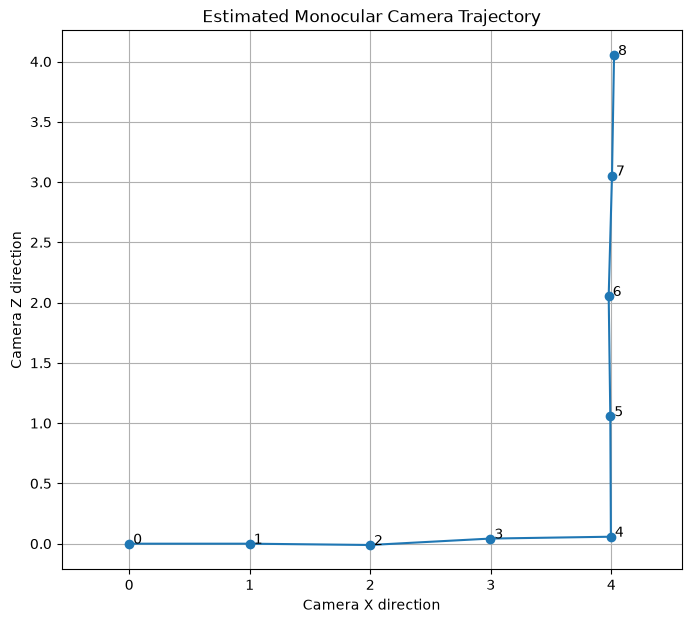

In [64]:
# ============================================================
# D6 — Visualize Estimated Camera Trajectory
# ============================================================

plt.figure(figsize=(8, 7))

plt.plot(
    trajectory[:, 0],
    trajectory[:, 2],
    marker="o"
)

for i, (x, z) in enumerate(
    zip(
        trajectory[:, 0],
        trajectory[:, 2]
    )
):

    plt.text(
        x,
        z,
        f" {i}"
    )


plt.xlabel("Camera X direction")
plt.ylabel("Camera Z direction")

plt.title(
    "Estimated Monocular Camera Trajectory"
)

plt.grid(True)
plt.axis("equal")

plt.show()

## D7. Ground-Truth Reference

The simulator provides the actual robot poses for every image.

We can therefore visualize the ground-truth robot path independently:

$$
(x,y)_{\text{ground truth}}
$$

The estimated visual trajectory is expressed in the camera coordinate system:

$$
(x,z)_{\text{camera}}
$$

These two trajectories should **not** be directly overlaid without knowing the camera-to-robot extrinsic transformation and resolving the monocular scale.

Instead, we use the ground truth to reason about whether the estimated visual motion is qualitatively consistent with the controlled robot motion.

This distinction is important in real robotic systems, where sensor coordinate frames and calibration must be handled explicitly.

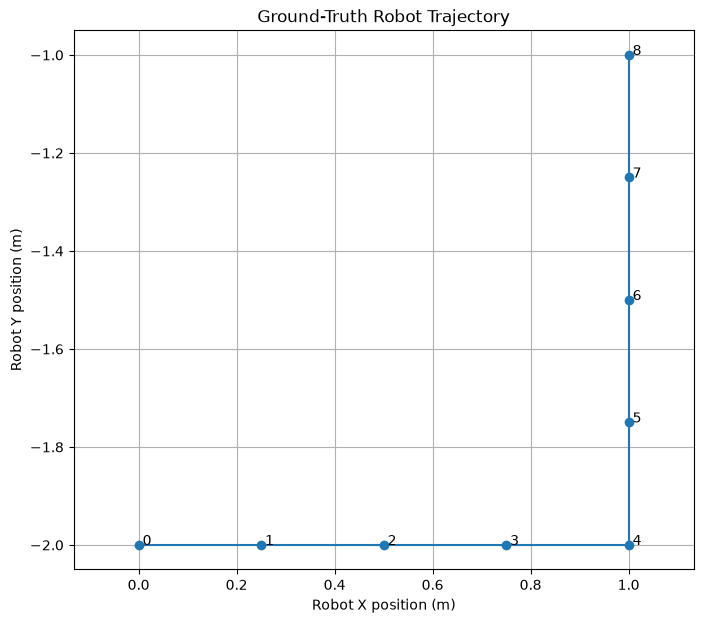

In [65]:
# ============================================================
# D7 — Visualize Ground-Truth Robot Path
# ============================================================

ground_truth = np.array([
    [row["x"], row["y"]]
    for row in sequence_rows
])


plt.figure(figsize=(8, 7))

plt.plot(
    ground_truth[:, 0],
    ground_truth[:, 1],
    marker="o"
)

for i, (x, y) in enumerate(ground_truth):

    plt.text(
        x,
        y,
        f" {i}"
    )


plt.xlabel("Robot X position (m)")
plt.ylabel("Robot Y position (m)")

plt.title(
    "Ground-Truth Robot Trajectory"
)

plt.grid(True)
plt.axis("equal")

plt.show()

## D8. Engineering Interpretation

The complete pipeline developed in this laboratory can now be summarized as:

$$
\boxed{
\text{Camera Images}
\rightarrow
\text{CNN Representation}
\rightarrow
\text{Visual Similarity}
\rightarrow
\text{Local Correspondences}
\rightarrow
\text{Geometric Motion}
\rightarrow
\text{Trajectory}
}
$$

The components have complementary roles:

| Component | Role |
|---|---|
| RGB camera | Observe the environment |
| ResNet18 | Learn a visual representation |
| Cosine similarity | Measure visual continuity |
| ORB | Establish local correspondences |
| RANSAC | Reject inconsistent correspondences |
| Essential Matrix | Estimate relative camera motion |
| Motion accumulation | Construct an estimated trajectory |

### Key engineering insight

Learned visual representations do not automatically replace geometric robotics algorithms.

A practical robotic perception system can combine:

$$
\boxed{
\text{Learning}
+
\text{Geometry}
}
$$

The CNN provides learned visual information, while geometric methods impose physical and spatial constraints on the estimated motion.

### Limitation

This laboratory demonstrates the visual front-end and trajectory-estimation aspects of a simplified Visual SLAM pipeline.

A production Visual SLAM system would additionally require components such as:

- scale estimation or additional sensors,
- landmark/map management,
- loop-closure detection,
- pose-graph optimization,
- uncertainty handling,
- and robust handling of dynamic objects.

## Checkpoint D — CNN-Assisted Visual Motion Estimation

Answer the following questions.

### Q1
What information does CNN cosine similarity provide that the Essential Matrix does not?

### Q2
Why can CNN similarity not directly provide the robot's translation in metres?

### Q3
Why is ORB/RANSAC still used after introducing the CNN representation?

### Q4
Why can the trajectory estimated from a monocular camera not be directly compared with the simulator's metric $(x,y)$ trajectory?

### Q5
A warehouse contains several visually identical racks. What problem could this create for a vision-based SLAM system?

### Q6
Name two additional sensors available on the warehouse AMR that could complement monocular visual odometry.